In [104]:


!pip install scikit-learn
!pip install xgboost


In [ ]:
!pip install scikit-learn

In [105]:
from sklearn.datasets import load_iris, load_breast_cancer, load_wine, load_diabetes
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn. metrics import accuracy_score, confusion_matrix, classification_report


In [106]:
!pip install xgboost

### Iris Flower Species Prediction by using Machine Learning

![alt text](https://editor.analyticsvidhya.com/uploads/51518iris%20img1.png)

In [107]:
iris=load_iris()

In [108]:
df = pd.DataFrame(iris.data, columns = iris.feature_names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [109]:
df["species"] = iris.target

### EDA (Exploraratory Data Analysis)

In [110]:
df.shape

(150, 5)

In [111]:
df.size

750

In [112]:
df.axes

[RangeIndex(start=0, stop=150, step=1),
 Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
        'petal width (cm)', 'species'],
       dtype='str')]

In [113]:
df.index

RangeIndex(start=0, stop=150, step=1)

In [114]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='str')

In [115]:
df.duplicated().sum()

np.int64(1)

In [116]:
df.drop_duplicates(inplace=True)

In [117]:
df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [118]:
df.info()

<class 'pandas.DataFrame'>
Index: 149 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  149 non-null    float64
 1   sepal width (cm)   149 non-null    float64
 2   petal length (cm)  149 non-null    float64
 3   petal width (cm)   149 non-null    float64
 4   species            149 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 7.0 KB


In [119]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,149.000000,149.000000,149.000000,149.000000,149.000000
mean,5.843624,3.059732,3.748993,1.194631,0.993289
std,0.830851,0.436342,1.767791,0.762622,0.817847
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.300000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### Univariate Analysis

In [120]:
# univariate analysis
def Univariate_Continuous_Data_Analysis(col):
    print(f"Analysis of Column : {col}")
    print("-"*50)

    stats_list = []
    stats_df = pd.DataFrame()
    stats_list.append(df[col].mean())
    stats_list.append(df[col].median())
    stats_list.append(df[col].var())
    stats_list.append(df[col].std())
    stats_list.append(df[col].max() - df[col].min())
    #print(stats_list)

    print(f"Analysis of a columns {col} by stats")
    print("-"*50)
    stats_df = pd.DataFrame(stats_list,index = ["Mean", "Median", "Var", "std", "range"], columns = [col])
    print(stats_df)

    print("-"*50)

In [121]:
Univariate_Continuous_Data_Analysis("sepal length (cm)")

Analysis of Column : sepal length (cm)
--------------------------------------------------
Analysis of a columns sepal length (cm) by stats
--------------------------------------------------
        sepal length (cm)
Mean             5.843624
Median           5.800000
Var              0.690314
std              0.830851
range            3.600000
--------------------------------------------------


In [122]:
Univariate_Continuous_Data_Analysis("sepal width (cm)")

Analysis of Column : sepal width (cm)
--------------------------------------------------
Analysis of a columns sepal width (cm) by stats
--------------------------------------------------
        sepal width (cm)
Mean            3.059732
Median          3.000000
Var             0.190395
std             0.436342
range           2.400000
--------------------------------------------------


In [123]:
Univariate_Continuous_Data_Analysis("petal length (cm)")

Analysis of Column : petal length (cm)
--------------------------------------------------
Analysis of a columns petal length (cm) by stats
--------------------------------------------------
        petal length (cm)
Mean             3.748993
Median           4.300000
Var              3.125083
std              1.767791
range            5.900000
--------------------------------------------------


In [124]:
Univariate_Continuous_Data_Analysis("petal width (cm)")

Analysis of Column : petal width (cm)
--------------------------------------------------
Analysis of a columns petal width (cm) by stats
--------------------------------------------------
        petal width (cm)
Mean            1.194631
Median          1.300000
Var             0.581593
std             0.762622
range           2.400000
--------------------------------------------------


In [125]:
def Unvariate_visualization(col):
    print(f"Visualization for : {col}")
    plt.figure(figsize=(5, 5))
    fig, ax = plt.subplots(1,2)
    sns.histplot(df[col], color = "red", ax = ax[0])
    sns.kdeplot(df[col], fill = True, color = "Orange",ax = ax[1])
    plt.tight_layout()

Visualization for : petal width (cm)


<Figure size 500x500 with 0 Axes>

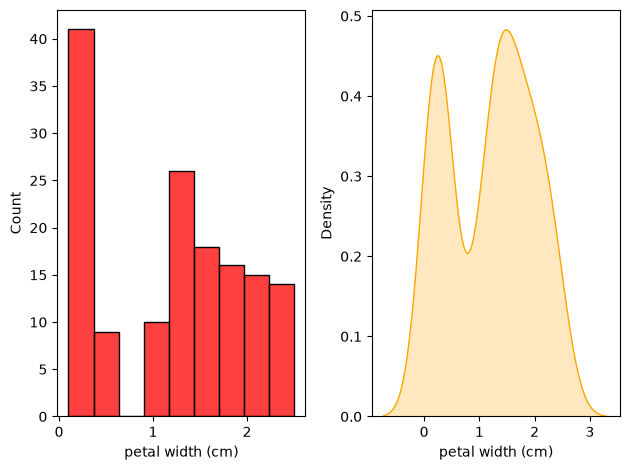

In [126]:
Unvariate_visualization("petal width (cm)")

Visualization for : petal length (cm)


<Figure size 500x500 with 0 Axes>

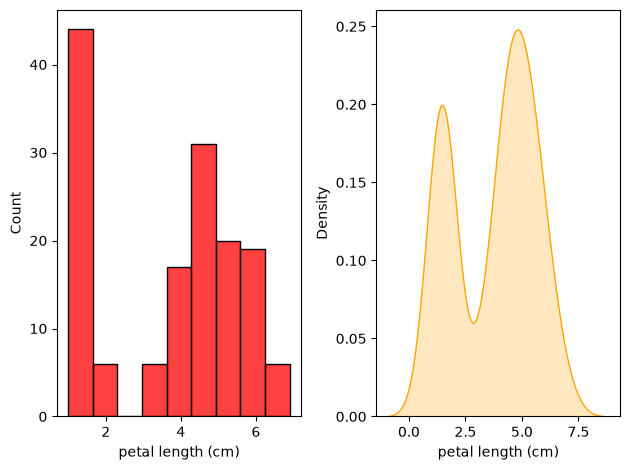

In [127]:
Unvariate_visualization("petal length (cm)")

Visualization for : sepal width (cm)


<Figure size 500x500 with 0 Axes>

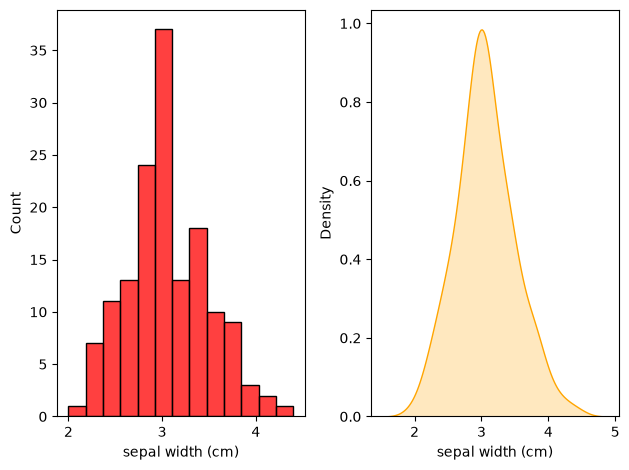

In [128]:
Unvariate_visualization("sepal width (cm)")

Visualization for : sepal length (cm)


<Figure size 500x500 with 0 Axes>

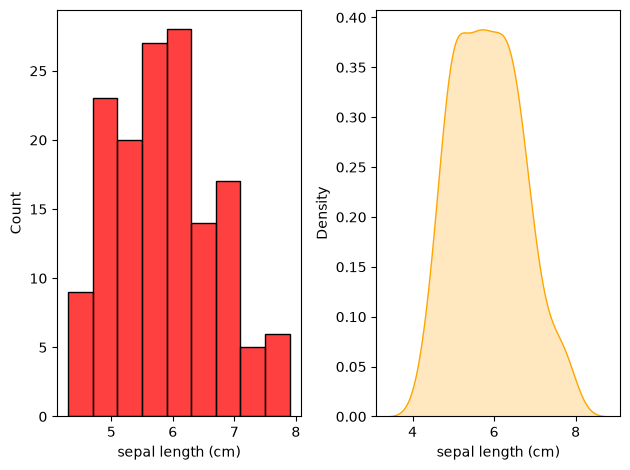

In [129]:
Unvariate_visualization("sepal length (cm)")

In [130]:
def Categorical_Data_Analysis(col):
    print(f"Analysis for column : {col}")
    print(f"No. Of Unique Values: {df[col].nunique()}")
    print(f"Unique Values : {df[col].unique()}")
    print(f"Value Count : {df[col].value_counts()}")
    print("-"*50)

In [131]:
Categorical_Data_Analysis("species")

Analysis for column : species
No. Of Unique Values: 3
Unique Values : [0 1 2]
Value Count : species
0    50
1    50
2    49
Name: count, dtype: int64
--------------------------------------------------


<Axes: xlabel='species', ylabel='count'>

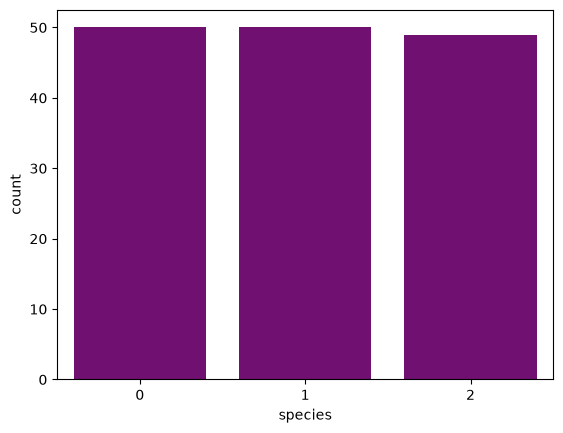

In [132]:
sns.countplot(x=df["species"], color = "purple")

### Bivariate Analysis

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

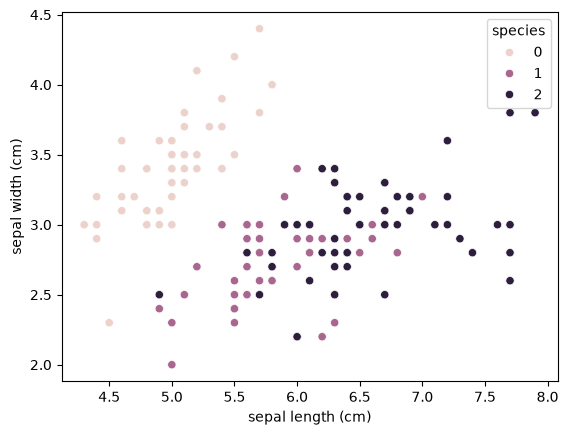

In [133]:
sns.scatterplot(x=df["sepal length (cm)"], y=df["sepal width (cm)"], hue = df["species"], color = "black")

<Axes: xlabel='sepal length (cm)', ylabel='petal width (cm)'>

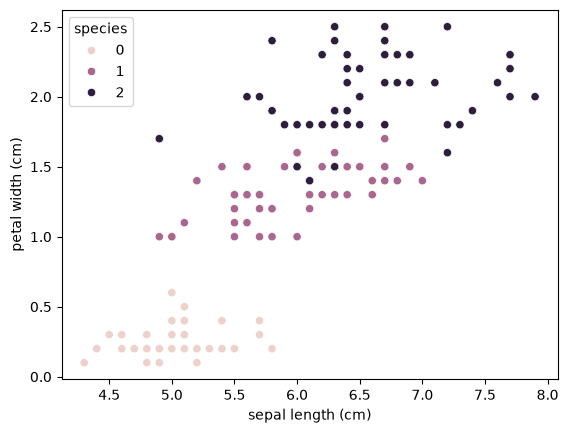

In [134]:
sns.scatterplot(x=df["sepal length (cm)"], y=df["petal width (cm)"], hue = df["species"], color = "black")

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

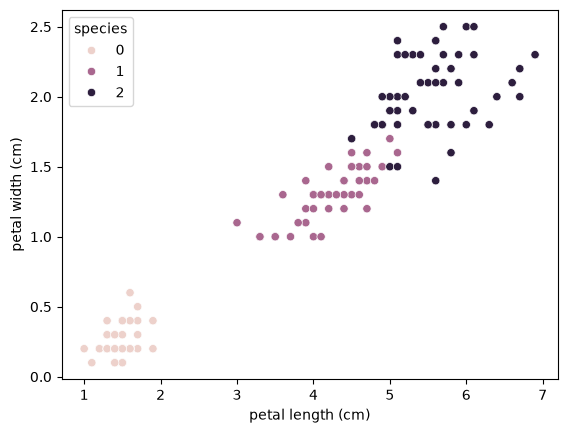

In [135]:
sns.scatterplot(x=df["petal length (cm)"], y=df["petal width (cm)"], hue = df["species"], color = "black")

<Axes: xlabel='sepal width (cm)', ylabel='petal width (cm)'>

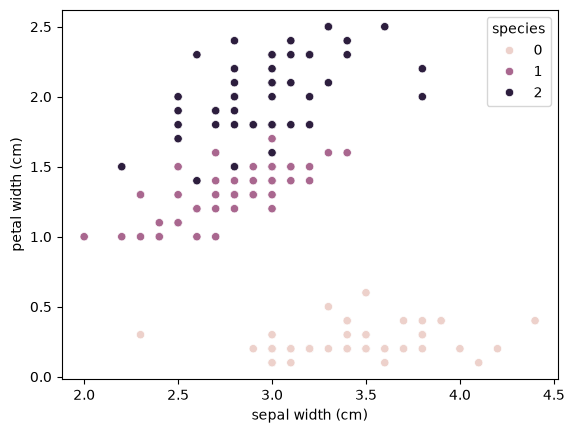

In [136]:
sns.scatterplot(x=df["sepal width (cm)"], y=df["petal width (cm)"],  hue = df["species"],color = "black")

### Multivariate Analysis and Feature Selection

In [137]:
df.info()

<class 'pandas.DataFrame'>
Index: 149 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  149 non-null    float64
 1   sepal width (cm)   149 non-null    float64
 2   petal length (cm)  149 non-null    float64
 3   petal width (cm)   149 non-null    float64
 4   species            149 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 7.0 KB


In [138]:
df.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
sepal length (cm),1.000000,-0.118129,0.873738,0.820620,0.786971
sepal width (cm),-0.118129,1.000000,-0.426028,-0.362894,-0.422987
petal length (cm),0.873738,-0.426028,1.000000,0.962772,0.949402
petal width (cm),0.820620,-0.362894,0.962772,1.000000,0.956514
species,0.786971,-0.422987,0.949402,0.956514,1.000000


<Axes: >

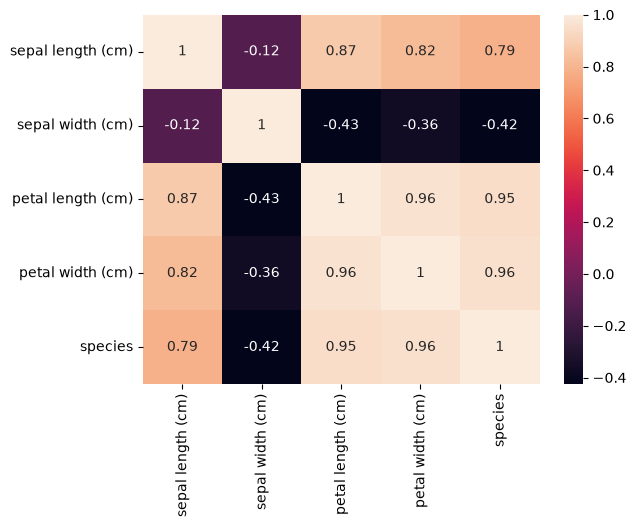

In [139]:
sns.heatmap(df.corr(),annot=True)

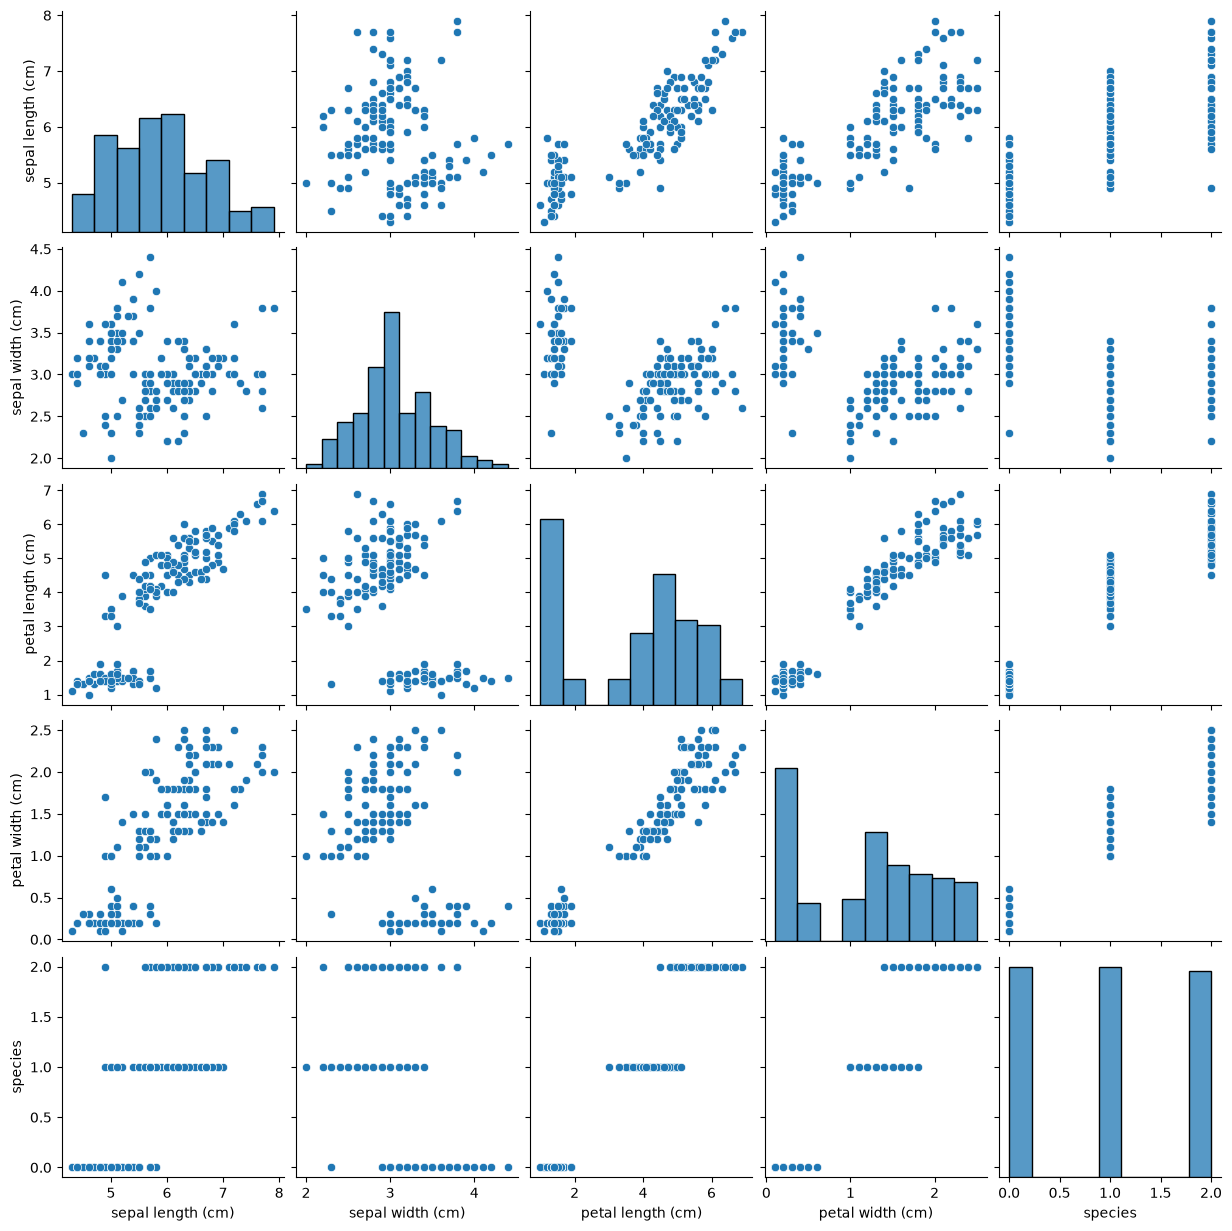

In [140]:
sns.pairplot(df)

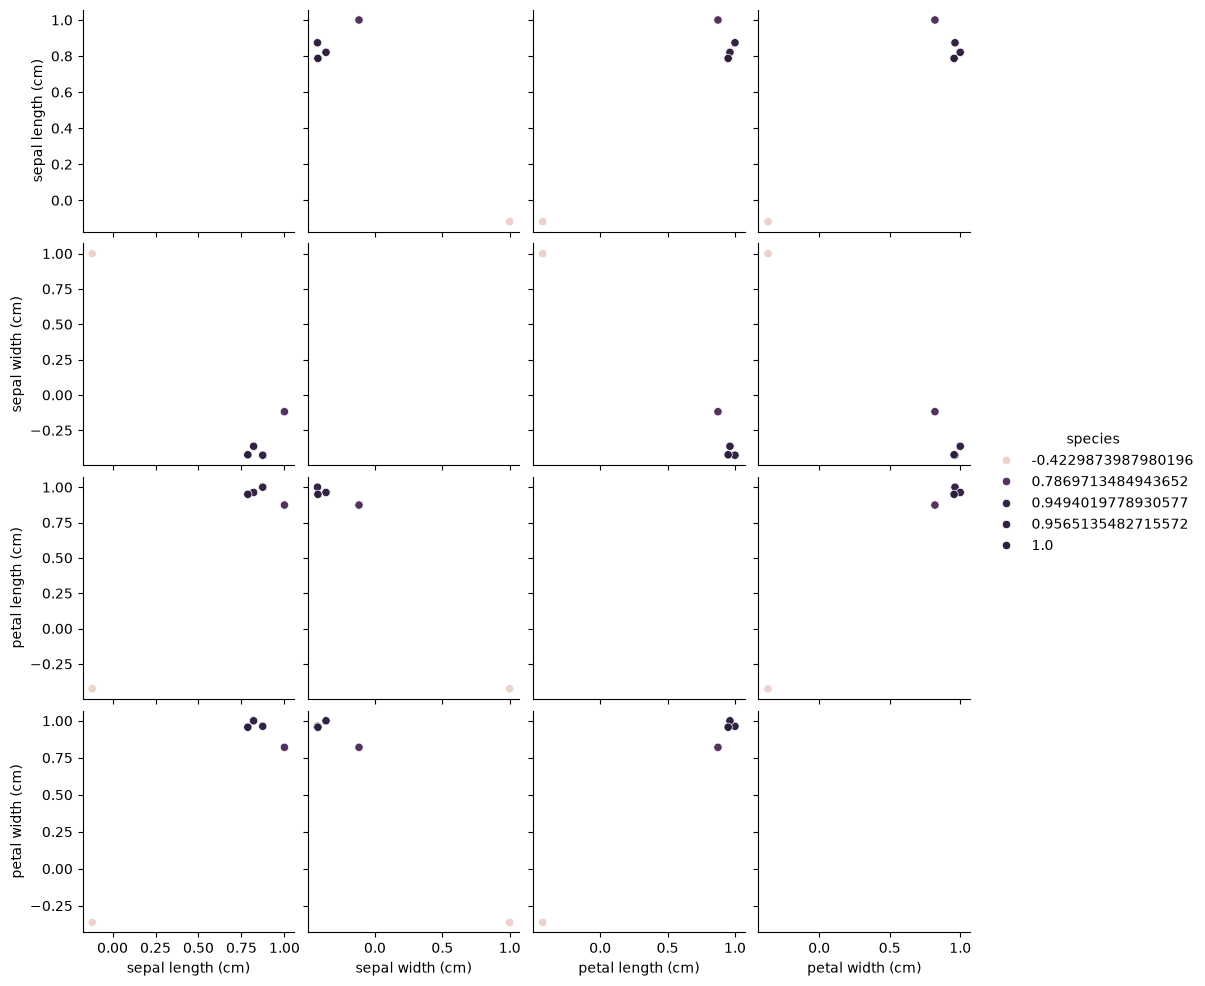

In [141]:
sns.pairplot(df.corr(), hue = "species")

### checking and handling Outliers

In [142]:
def checking_and_handling_of_outliers(col):
    print(f"Checking and Handling of Outliers for {col}")
    sns.boxplot(df[col], color = "pink")

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3-q1

    lowertail = q1-1.5*iqr
    uppertail = q3+1.5*iqr

    print("-"*60)
    print(f"LowerTail = {lowertail}")
    print(f"UpperTail = {uppertail}")
    print("-"*60)

    outliers = df[(df[col]<lowertail) | (df[col]>uppertail)]

    if len(outliers) == 0 :
        print("No Outliers")
    else:
        print(outliers)

    # handling of outliers
    df.loc[df[col]<lowertail, col] = lowertail
    df.loc[df[col]>uppertail, col] = uppertail


Checking and Handling of Outliers for sepal length (cm)
------------------------------------------------------------
LowerTail = 3.1499999999999986
UpperTail = 8.350000000000001
------------------------------------------------------------
No Outliers


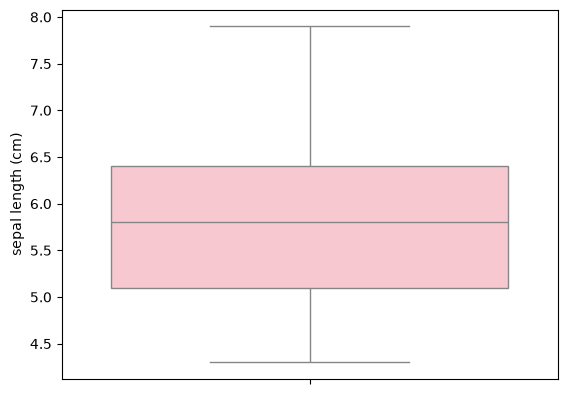

In [143]:
checking_and_handling_of_outliers("sepal length (cm)")

Checking and Handling of Outliers for sepal width (cm)
------------------------------------------------------------
LowerTail = 2.05
UpperTail = 4.05
------------------------------------------------------------
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
15                5.7               4.4                1.5               0.4   
32                5.2               4.1                1.5               0.1   
33                5.5               4.2                1.4               0.2   
60                5.0               2.0                3.5               1.0   

    species  
15        0  
32        0  
33        0  
60        1  


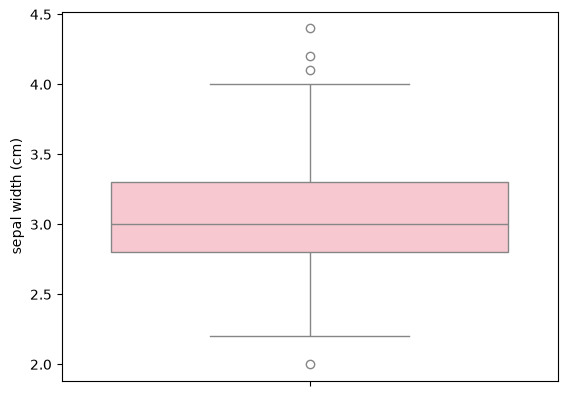

In [144]:
checking_and_handling_of_outliers("sepal width (cm)")

Checking and Handling of Outliers for petal width (cm)
------------------------------------------------------------
LowerTail = -1.95
UpperTail = 4.05
------------------------------------------------------------
No Outliers


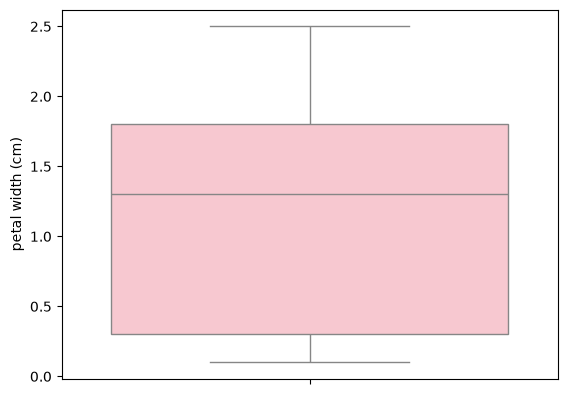

In [145]:
checking_and_handling_of_outliers("petal width (cm)")

Checking and Handling of Outliers for petal length (cm)
------------------------------------------------------------
LowerTail = -3.649999999999999
UpperTail = 10.349999999999998
------------------------------------------------------------
No Outliers


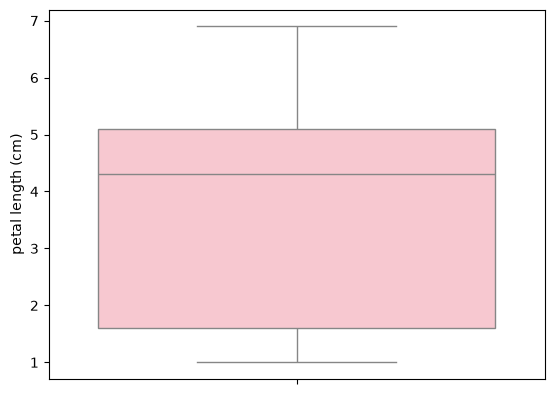

In [146]:
checking_and_handling_of_outliers("petal length (cm)")

In [147]:
x = df.drop("species", axis = 1)

y = df["species"]

In [148]:
x.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='str')

In [149]:
x.shape

(149, 4)

### Test Train split

In [150]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size=0.2, random_state=10)

In [151]:
xtrain.shape

(119, 4)

In [152]:
xtest.shape

(30, 4)

### Model Training and Evalution

## Algorithm 1 : Logistic Regression

In [153]:
from IPython.core import logger
log_reg = LogisticRegression()
print(log_reg)
log_reg_model = log_reg.fit(xtrain, ytrain)
log_reg_model

LogisticRegression()


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [154]:
ytrain_pred = log_reg_model.predict(xtrain)
ytest_pred = log_reg_model.predict(xtest)

### Evaluation of Training Data
#### model evalution for training data

In [155]:
print("Model Evaluation for Training Data")
print("-"* 50)
acc = accuracy_score(ytrain, ytrain_pred)
print(f"Accuracy = {acc}")
print("-"* 50)

conf_mat = confusion_matrix(ytrain, ytrain_pred)
print(f"Confusion Matrix = \n{conf_mat}")
print("-"* 50)

clf_report = classification_report(ytrain, ytrain_pred)
print(f"Classification Report = \n{clf_report}")
print("-"* 50)

Model Evaluation for Training Data
--------------------------------------------------
Accuracy = 0.9831932773109243
--------------------------------------------------
Confusion Matrix = 
[[41  0  0]
 [ 0 34  2]
 [ 0  0 42]]
--------------------------------------------------
Classification Report = 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      0.94      0.97        36
           2       0.95      1.00      0.98        42

    accuracy                           0.98       119
   macro avg       0.98      0.98      0.98       119
weighted avg       0.98      0.98      0.98       119

--------------------------------------------------


### Model evaluation for testing data

In [156]:
print("Model Evaluation for testing Data")
print("-"* 50)
acc = accuracy_score(ytest, ytest_pred)
print(f"Accuracy = {acc}")
print("-"* 50)

conf_mat = confusion_matrix(ytest, ytest_pred)
print(f"Confusion Matrix = \n{conf_mat}")
print("-"* 50)

clf_report = classification_report(ytest, ytest_pred)
print(f"Classification Report = \n{clf_report}")
print("-"* 50)

Model Evaluation for testing Data
--------------------------------------------------
Accuracy = 0.9666666666666667
--------------------------------------------------
Confusion Matrix = 
[[ 9  0  0]
 [ 0 13  1]
 [ 0  0  7]]
--------------------------------------------------
Classification Report = 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      0.93      0.96        14
           2       0.88      1.00      0.93         7

    accuracy                           0.97        30
   macro avg       0.96      0.98      0.97        30
weighted avg       0.97      0.97      0.97        30

--------------------------------------------------


### Algorithm 2: KNN

In [157]:
knn_reg= KNeighborsClassifier()
knn_model = knn_reg.fit(xtrain, ytrain)
knn_model

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [158]:
# model evaluation for training data


print("Model Evaluation for Training Data")
print("-"* 50)
acc = accuracy_score(ytrain, ytrain_pred)
print(f"Accuracy = {acc}")
print("-"* 50)

conf_mat = confusion_matrix(ytrain, ytrain_pred)
print(f"Confusion Matrix = \n{conf_mat}")
print("-"* 50)

clf_report = classification_report(ytrain, ytrain_pred)
print(f"Classification Report = \n{clf_report}")
print("-"* 50)


# model evaluation for testing data

print("Model Evaluation for testing Data")
print("-"* 50)
acc = accuracy_score(ytest, ytest_pred)
print(f"Accuracy = {acc}")
print("-"* 50)

conf_mat = confusion_matrix(ytest, ytest_pred)
print(f"Confusion Matrix = \n{conf_mat}")
print("-"* 50)

clf_report = classification_report(ytest, ytest_pred)
print(f"Classification Report = \n{clf_report}")
print("-"* 50)

Model Evaluation for Training Data
--------------------------------------------------
Accuracy = 0.9831932773109243
--------------------------------------------------
Confusion Matrix = 
[[41  0  0]
 [ 0 34  2]
 [ 0  0 42]]
--------------------------------------------------
Classification Report = 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      0.94      0.97        36
           2       0.95      1.00      0.98        42

    accuracy                           0.98       119
   macro avg       0.98      0.98      0.98       119
weighted avg       0.98      0.98      0.98       119

--------------------------------------------------
Model Evaluation for testing Data
--------------------------------------------------
Accuracy = 0.9666666666666667
--------------------------------------------------
Confusion Matrix = 
[[ 9  0  0]
 [ 0 13  1]
 [ 0  0  7]]
---------------------------------------------

### 3 Decision Tree

In [159]:
d_tree = DecisionTreeClassifier( max_depth = 3)
dt_model = d_tree.fit(xtrain, ytrain)
dt_model

ytrain_pred_dt = dt_model.predict(xtrain)
ytest_pred_dt = dt_model.predict(xtest)

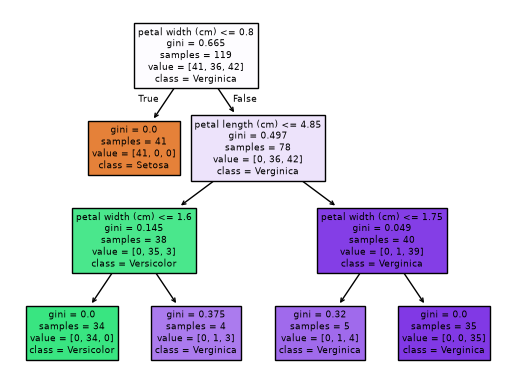

In [160]:
plot_tree(dt_model,feature_names=x.columns, class_names=["Setosa", "Versicolor", "Verginica"], filled=True)
plt.show()

### 4 Random Forest

In [161]:
rmf = RandomForestClassifier()
rmf_model = rmf.fit(xtrain, ytrain)
rmf_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [162]:
ytrain_pred_rmf = rmf_model.predict(xtrain)
ytest_pred_rmf = rmf_model.predict(xtest)

In [163]:
print("---"*45)
print("Model Evaluation for Training Data")
print("---"*45)

acc = accuracy_score(ytrain, ytrain_pred_rmf)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytrain, ytrain_pred_rmf)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytrain, ytrain_pred_rmf)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Training Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 1.0
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[41  0  0]
 [ 0 36  0]
 [ 0  0 42]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00        36
           2       1.00      1.00      1.00        42

    accuracy                           1.00       119
   macro avg       1.00      1.00      1.00       11

In [164]:
print("---"*45)
print("Model Evaluation for Testing Data")
print("---"*45)

acc = accuracy_score(ytest, ytest_pred_rmf)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytest, ytest_pred_rmf)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytest, ytest_pred_rmf)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Testing Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 0.9333333333333333
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[ 9  0  0]
 [ 0 12  2]
 [ 0  0  7]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      0.86      0.92        14
           2       0.78      1.00      0.88         7

    accuracy                           0.93        30
   macro avg       0.93      0.95     

### 5 Adaboost

In [165]:
adc = AdaBoostClassifier()
adc_model = adc.fit(xtrain, ytrain)
adc_model

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](3,)","[0,1,2]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](50,)","[0.3 ,0.17,0.1 ,...,0.22,0.31,0.24]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](50,)","[1.53,2.29,2.84,...,1.97,1.48,1.86]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=2145915844), DecisionTreeC...tate=21168275), DecisionTreeC...ate=222491746), DecisionTreeC...ate=458827595), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](4,)","[0.11,0.08,0.51,0.3 ]"


In [166]:
ytrain_pred_adc = adc_model.predict(xtrain)
ytest_pred_adc = adc_model.predict(xtest)

In [167]:
print("---"*45)
print("Model Evaluation for Training Data")
print("---"*45)

acc = accuracy_score(ytrain, ytrain_pred_adc)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytrain, ytrain_pred_adc)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytrain, ytrain_pred_adc)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Training Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 1.0
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[41  0  0]
 [ 0 36  0]
 [ 0  0 42]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00        36
           2       1.00      1.00      1.00        42

    accuracy                           1.00       119
   macro avg       1.00      1.00      1.00       11

In [168]:
print("---"*45)
print("Model Evaluation for Testing Data")
print("---"*45)

acc = accuracy_score(ytest, ytest_pred_adc)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytest, ytest_pred_adc)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytest, ytest_pred_adc)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Testing Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 0.9333333333333333
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[ 9  0  0]
 [ 0 12  2]
 [ 0  0  7]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      0.86      0.92        14
           2       0.78      1.00      0.88         7

    accuracy                           0.93        30
   macro avg       0.93      0.95     

### 6 Gradient Boost

In [169]:
gra = GradientBoostingClassifier()
gra_model = gra.fit(xtrain, ytrain)
gra_model

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init init: estimator or 'zero', default=NoneAn estimator object that is used to co

In [170]:
ytrain_pred_gra = gra_model.predict(xtrain)
ytest_pred_gra = gra_model.predict(xtest)

In [171]:
print("---"*45)
print("Model Evaluation for Training Data")
print("---"*45)

acc = accuracy_score(ytrain, ytrain_pred_gra)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytrain, ytrain_pred_gra)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytrain, ytrain_pred_gra)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Training Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 1.0
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[41  0  0]
 [ 0 36  0]
 [ 0  0 42]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00        36
           2       1.00      1.00      1.00        42

    accuracy                           1.00       119
   macro avg       1.00      1.00      1.00       11

In [172]:
print("---"*45)
print("Model Evaluation for Testing Data")
print("---"*45)

acc = accuracy_score(ytest, ytest_pred_gra)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytest, ytest_pred_gra)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytest, ytest_pred_gra)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Testing Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 0.9333333333333333
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[ 9  0  0]
 [ 0 12  2]
 [ 0  0  7]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      0.86      0.92        14
           2       0.78      1.00      0.88         7

    accuracy                           0.93        30
   macro avg       0.93      0.95     

### 7 XGBoost

In [173]:
xgb = XGBClassifier()
xgb_model = xgb.fit(xtrain, ytrain)
xgb_model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [174]:
ytrain_pred_xgb = xgb_model.predict(xtrain)
ytest_pred_xgb = xgb_model.predict(xtest)

In [175]:
print("---"*45)
print("Model Evaluation for Training Data")
print("---"*45)

acc = accuracy_score(ytrain, ytrain_pred_xgb)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytrain, ytrain_pred_xgb)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytrain, ytrain_pred_xgb)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Training Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 1.0
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[41  0  0]
 [ 0 36  0]
 [ 0  0 42]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00        36
           2       1.00      1.00      1.00        42

    accuracy                           1.00       119
   macro avg       1.00      1.00      1.00       11

In [176]:
print("---"*45)
print("Model Evaluation for Testing Data")
print("---"*45)

acc = accuracy_score(ytest, ytest_pred_xgb)
print(f"Accuracy = {acc}")
print("---"*45)

conf_mat = confusion_matrix(ytest, ytest_pred_xgb)
print(f"Confusion Matric = \n{conf_mat}")
print("---"*45)

clf_report = classification_report(ytest, ytest_pred_xgb)
print(f"Classification Report = \n{clf_report}")
print("---"*45)

---------------------------------------------------------------------------------------------------------------------------------------
Model Evaluation for Testing Data
---------------------------------------------------------------------------------------------------------------------------------------
Accuracy = 0.9
---------------------------------------------------------------------------------------------------------------------------------------
Confusion Matric = 
[[ 9  0  0]
 [ 1 11  2]
 [ 0  0  7]]
---------------------------------------------------------------------------------------------------------------------------------------
Classification Report = 
              precision    recall  f1-score   support

           0       0.90      1.00      0.95         9
           1       1.00      0.79      0.88        14
           2       0.78      1.00      0.88         7

    accuracy                           0.90        30
   macro avg       0.89      0.93      0.90        30

### Save Model in . Pkl file

In [177]:
import pickle
with open("FinalModel.pkl", "wb") as f:
    pickle.dump(log_reg_model, f)

In [178]:
with open("FinalModel.pkl", "rb") as f:
    FinalModel = pickle.load(f)

FinalModel

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [179]:
xtest.head(1)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
81,5.5,2.4,3.7,1.0


In [180]:
ytest

81     1
132    2
10     0
87     1
52     1
56     1
58     1
83     1
39     0
148    2
146    2
141    2
66     1
1      0
19     0
108    2
82     1
38     0
21     0
35     0
72     1
118    2
53     1
24     0
67     1
2      0
84     1
140    2
98     1
85     1
Name: species, dtype: int64

In [181]:
if FinalModel.predict(xtest.head(1))[0] == 0 :
    print("Iris - Setosa")
elif FinalModel.predict(xtest.head(1))[0] == 1:
    print("Iris - Versicolor")
else:
    print("Iris - Verginica")

Iris - Versicolor


In [182]:
import pickle

with open("gra_model.pkl", "wb") as file:
    pickle.dump(gra_model, file)

In [183]:
with open("gra_model.pkl", "rb") as f:
    gra_model = pickle.load(f)

gra_model

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init init: estimator or 'zero', default=NoneAn estimator object that is used to co

In [184]:
xtest.head(1)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
81,5.5,2.4,3.7,1.0


In [185]:
ytest

81     1
132    2
10     0
87     1
52     1
56     1
58     1
83     1
39     0
148    2
146    2
141    2
66     1
1      0
19     0
108    2
82     1
38     0
21     0
35     0
72     1
118    2
53     1
24     0
67     1
2      0
84     1
140    2
98     1
85     1
Name: species, dtype: int64

In [186]:
if FinalModel.predict(xtest.head(1))[0] == 0 :
    print("Iris - Setosa")
elif FinalModel.predict(xtest.head(1))[0] == 1:
    print("Iris - Versicolor")
else:
    print("Iris - Verginica")

Iris - Versicolor
